In [1]:
import os
import sys

# Specify the path to your NKT folder (update as needed)
nkt_dir = r"D:\OneDrive\UCSC\Research\MMI\Code\Thorcam_kiralux_python\NKT"

# Ensure Python can find NKTP_DLL.py
if nkt_dir not in sys.path:
    sys.path.insert(0, nkt_dir)

# For Windows: help Python locate NKTPDLL.dll (recommended for Python 3.8+)
if hasattr(os, "add_dll_directory"):
    os.add_dll_directory(nkt_dir)

from NKTP_DLL import *
print("NKTP_DLL imported successfully.")

import time
import numpy as np
import pandas as pd
from sys import getsizeof
import socket
import csv
import colorama
from colorama import Fore

# 1. Automatically locate your SDK source code folder.
# Assuming the SDK folder is inside Thorcam_kiralux_python.
sdk_parent_dir = os.path.join(os.getcwd(), "Thorcam_kiralux_python")

# 2. Add this path to the system search path.
if sdk_parent_dir not in sys.path:
    sys.path.append(sdk_parent_dir)

# 3. Try importing the Thorlabs SDK to verify it's available.
try:
    from thorlabs_tsi_sdk.tl_camera import TLCameraSDK
    print("Thorlabs SDK import successful!")
except ImportError as e:
    print(f"Import failed: {e}")
    print("Please ensure that there's a subfolder named 'thorlabs_tsi_sdk' inside the Thorcam_kiralux_python folder.")

Loading x64 DLL from: D:\NKT\SDK\NKTPDLL\x64\NKTPDLL.dll
NKTP_DLL imported successfully.
Thorlabs SDK import successful!


# Connect Kiralux

In [2]:
import os
import numpy as np
# import tiffile as tifff
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from thorlabs_tsi_sdk.tl_camera import TLCameraSDK
from thorlabs_tsi_sdk.tl_mono_to_color_processor import MonoToColorProcessorSDK
# import cv2

import PIL
import re
import gc
from thorlabs_tsi_sdk.tl_camera_enums import SENSOR_TYPE

# --- Key modification section starts ---
# Use the Native_64_lib folder in the current directory as the DLL path
DLL_PATH = os.path.abspath("./Native_64_lib")

# Add DLL_PATH to the beginning of the PATH environment variable for the current process
os.environ['PATH'] = DLL_PATH + os.pathsep + os.environ['PATH']

# For Python 3.8+, using os.add_dll_directory is a more reliable way to load DLLs
try:
    os.add_dll_directory(DLL_PATH)
    print(f"Added DLL directory: {DLL_PATH}") # Confirm that the DLL directory was added
except AttributeError:
    # os.add_dll_directory is not available on Python versions below 3.8
    print("os.add_dll_directory not available (Python < 3.8)")
    pass
# --- Key modification section ends ---

# Import the Thorlabs SDK. It should now be able to find the required DLLs.
from thorlabs_tsi_sdk.tl_camera import TLCameraSDK

print("Attempting to initialize TLCameraSDK...")
with TLCameraSDK() as sdk:
    available_cameras = sdk.discover_available_cameras()
    if len(available_cameras) < 1:
        print("No cameras detected.")
    else:
        print('Available cameras:')
        print(available_cameras) # Should display camera serial number, e.g., ['23554']

        with sdk.open_camera(available_cameras[0]) as camera:
            # Set region of interest (ROI) to the full frame
            camera.roi = (0, 0, 4096, 2160) #(x1, y1, x2, y2) not (x0, y0, w, h)!!!!!!!!!!!
       
            print(f"Camera ROI set to full frame: {camera.roi}")
     
            # If needed, you can uncomment the lines below to print other camera parameters:
            # print(f'SENSOR TYPE: {camera.camera_sensor_type}')
            # print(f'Cooling status: {camera.is_cooling_enabled}')
            # print(f'Exposure range (us): {camera.exposure_time_range_us}')
            # print(f'Gain range: {camera.gain_range}')
            # camera.is_led_on = False  # Uncomment if needed

Added DLL directory: d:\OneDrive\UCSC\Research\MMI\Code\Thorcam_kiralux_python\Native_64_lib
Attempting to initialize TLCameraSDK...
Available cameras:
['23554']
Camera ROI set to full frame: ROI(upper_left_x_pixels=0, upper_left_y_pixels=0, lower_right_x_pixels=4095, lower_right_y_pixels=2159)


## Test


In [4]:
num_images=1  


###for taking ref image
exposure_time_ms= 0.036   #max- 22806346 us=22806.346 #min- 0.03ms
gain= 0  #0 to 480, 480 means 48dB
timeout_ms=5000   #must be significantly larger than exposure time



In [5]:
start_index=0

with TLCameraSDK() as sdk:
    available_cameras = sdk.discover_available_cameras()
    if len(available_cameras) < 1:
        print("no cameras detected")

    with sdk.open_camera(available_cameras[0]) as camera:
        camera.exposure_time_us = int(exposure_time_ms*1000)  # set exposure 
        camera.frames_per_trigger_zero_for_unlimited = 0  # start camera in continuous mode
        camera.image_poll_timeout_ms = int(timeout_ms)  # polling timeout
        old_roi = camera.roi  # store the current roi
        """
        uncomment the line below to set a region of interest (ROI) on the camera
        """

        """
        uncomment the lines below to set the gain of the camera and read it back in decibels
        """
        camera.gain = int(gain)

        #####operation starts
        camera.arm(2)

        camera.issue_software_trigger()

        for i in range(num_images):
            frame = camera.get_pending_frame_or_null()
            if frame is not None:
                print("frame #{} received!".format(frame.frame_count))

                # NOTE: frame.image_buffer is a temporary memory buffer that may be overwritten during the next call
                # to get_pending_frame_or_null. The following line makes a deep copy of the image data:
                image_buffer_copy = np.copy(frame.image_buffer)
                
                with open(f'img{int(i+start_index)}.dat', 'wb') as file:
                    file.write(image_buffer_copy)   # 保存全图
            else:
                print("timeout reached during polling, program exiting...")
                break
        camera.disarm()
        camera.roi = old_roi  # reset the roi back to the original roi

# Because we are using the 'with' statement context-manager, disposal has been taken care of.

print("program completed")

frame #1 received!
program completed


ROI mean value: 5.49
ROI max value: 14
ROI min value: 1
ROI std deviation: 0.86
ROI median: 5.0


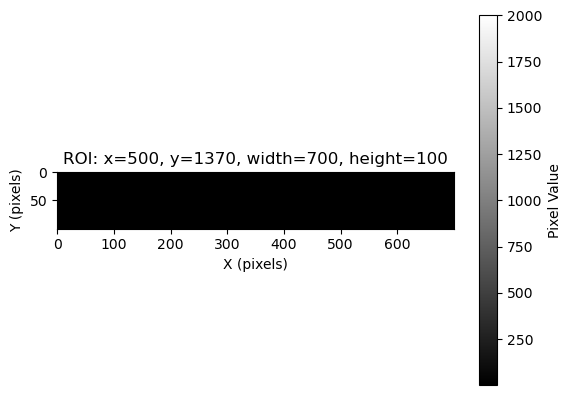

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Read img0.dat file (assuming the saved data is uint16 pixel values)
roi_width = 4096
roi_height = 2160

with open(r'D:\OneDrive\UCSC\Research\MMI\Code\Thorcam_kiralux_python\img0.dat', 'rb') as f:
    data = np.frombuffer(f.read(), dtype=np.uint16)

expected_size = roi_width * roi_height
if data.size != expected_size:
    print(f"Warning: Number of data elements {data.size} does not match expected ROI size {roi_width}x{roi_height}={expected_size}!")

image = data.reshape((roi_height, roi_width))

# Select ROI: upper-left corner (x0, y0), width w, height h
x0, y0, w, h = 500, 1370, 700, 100
roi_image = image[y0:y0+h, x0:x0+w]

# Calculate and print ROI image statistics
mean_value = np.mean(roi_image)
max_value = np.max(roi_image)
min_value = np.min(roi_image)
std_value = np.std(roi_image)
median_value = np.median(roi_image)
print(f"ROI mean value: {mean_value:.2f}")
print(f"ROI max value: {max_value}")
print(f"ROI min value: {min_value}")
print(f"ROI std deviation: {std_value:.2f}")
print(f"ROI median: {median_value}")

plt.imshow(roi_image, cmap='gray', vmin=1, vmax=2000)
plt.title(f"ROI: x={x0}, y={y0}, width={w}, height={h}")
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.colorbar(label='Pixel Value')
plt.show()

# Connect NKT Select

In [7]:
print('Find modules on all existing and accessible ports - Might take a few seconds to complete.....')
if (getLegacyBusScanning()):
    print('Scanning following ports in legacy mode:', getAllPorts())
else:
    print('Scanning following ports in normal mode:', getAllPorts())

# Use the openPorts function with Auto & Live settings. This will scan and detect modules
# on all ports returned by the getAllPorts function.
# Please note that a port being in use by another application, will show up in this list but will
# not show any devices due to this port being inaccessible.
print(openPorts(getAllPorts(), 1, 1))

# All ports returned by the getOpenPorts function has modules (ports with no modules will automatically be closed)
print('Following ports has modules:', getOpenPorts())

# Traverse the getOpenPorts list and retrieve found modules via the deviceGetAllTypes function
portlist = getOpenPorts().split(',')
for portName in portlist:
    result, devList = deviceGetAllTypes(portName)
    print(result,type(devList))
    for devId in range(0, len(devList)):
        if (devList[devId] != 0):
#             print('Comport:',portName,'Device type:',"0x%0.2X" % devList[devId],'at address:',devId)
            if devList[devId]==0x60:
                extreme=devId
            elif devList[devId]==0x61:
                extreme_fp=devId
            elif devList[devId]==0x66:
                RF_power=devId
            elif devList[devId]==0x67:
                SuperK_select=devId
    print(f"device address:\nextreme@ {extreme},extreme_fp@ {extreme_fp},RF_power@ {RF_power},SuperK_select@ {SuperK_select} ")
closeResult = closePorts('')
print('Close result: ', PortResultTypes(closeResult))

Find modules on all existing and accessible ports - Might take a few seconds to complete.....
Scanning following ports in normal mode: COM3
0
Following ports has modules: COM3
0 <class 'NKTP_DLL.c_ubyte_Array_255'>
device address:
extreme@ 15,extreme_fp@ 1,RF_power@ 27,SuperK_select@ 16 
Close result:  0:OPSuccess




## NKT Function defs

In [8]:
def Extreme_turnON(comport, extreme, emissionpercent):
    status=registerRead(comport,extreme,0x66,-1)
    time.sleep(0.5)
    if int.from_bytes(status[1], "little") & 0x01 == 0x00:
        result = registerWriteU16(comport,extreme,0x31,0x01,-1)  #constant power mode
        print('Setting constant power mode - Extreme:', RegisterResultTypes(result))
        time.sleep(0.2)
        
        emission=emissionpercent*10
        result = registerWriteU16(comport, extreme, 0x37, emission, -1)
        print('Setting emission level - Extreme:', RegisterResultTypes(result))
        time.sleep(0.2)
        
        result = registerWriteU8(comport, extreme, 0x30, 0x03, -1)
        print('Setting emission ON - Extreme:', RegisterResultTypes(result))
        time.sleep(0.5)
        
        
def crystal_select(comport,RF_power,SuperK_select, crystal_num):
    #crystal num: 0- vis/nir, 1- nir/ir
    result = registerRead(comport,RF_power,0x75,-1)
    time.sleep(0.2)
    print(result)
    if int.from_bytes(result[1], "little") != (crystal_num+1):
        result = registerWriteU8(comport, RF_power, 0x30, 0x00, -1)
        print(result)
        time.sleep(0.2)
        result = registerWriteU8(comport, SuperK_select, 0x34, 0x00, -1)
        print(result)
        time.sleep(0.2)
        result = registerRead(comport,RF_power,0x75,-1)
        time.sleep(0.2)
        if int.from_bytes(result[1], "little") != (crystal_num+1):
            result = registerWriteU8(comport, SuperK_select, 0x34, 0x01, -1)
            print(result)
            time.sleep(0.2)
        result = registerWriteU8(comport, SuperK_select, 0x35, crystal_num, -1)
        print(result)
        time.sleep(0.2)
        result = registerRead(comport,RF_power,0x75,-1)
        time.sleep(0.2)
        print(result)
        
def RF_turnON(comport,RF_power):
    for i in range(8):
        result=registerWriteU16(comport, RF_power, 0xB0+i,0,-1) #set all channel amplitude to 0
        time.sleep(0.2)
        print(result)
    status=registerRead(comport,RF_power,0x66,-1)
    if int.from_bytes(status[1], "little") & 0x01 == 0x00:
        result = registerWriteU8(comport, RF_power, 0x30, 0x01, -1)
        print('Turn RF Power ON:', RegisterResultTypes(result))
        time.sleep(0.2)
        
def RF_turnOFF(comport,RF_power):
    result = registerWriteU8(comport, RF_power, 0x30, 0x00, -1)
    print('Turn off RF Power:', RegisterResultTypes(result))
    time.sleep(0.2)
    
def Extreme_turnOFF(comport, extreme):
    result = registerWriteU8(comport, extreme, 0x30, 0x00, -1)
    print('Setting emission OFF - Extreme:', RegisterResultTypes(result))
    time.sleep(0.2)
def set_nkt(comport, RF_power,wavelength):
    result = registerWriteU32(comport, RF_power, 0x90, wavelength, -1)
    time.sleep(0.2)
    return result
# result=registerWriteU16('COM5', RF_power, 0xB0,1000,-1)
# wl=int(670.5*1000)
# result = set_nkt('COM5',RF_power,wl)
# print(result)

# OSA Function defs

In [15]:
def sock_send(sock,msg,receive=False,cond=None):
    sock.send(msg.encode()+b"\r\n")
    if receive:
        if cond != None:
            data = b'0'
            while data.decode("utf-8")[0] != cond:
                sock.send(b":stat:oper:even?\r\n")
                data = sock.recv(1024)

                time.sleep(0.1)
#             print(data)
            return data
        else:
            data = sock.recv(1024)
#             print(data)
            return data
    return None

def sock_send_arr(sock,msg_list,receive=False):
    ret = []
    for msg in msg_list:
        ret += [sock_send(sock,msg,receive)]
    return ret

def querry_data(sock,msg):
    sock.send(msg.encode()+b"\r\n")  
    strData2=b""
    i=0
    while True:
#         print(f"iter{i}")
        i=i+1
        strData2=sock.recv(1024)
#         print(strData2)
        if strData2.decode("utf-8")[0]=="+":
            break  
    return strData2.decode("utf-8")

# OSA User Inputs

In [16]:
#**********remember to move ALL FILES (IMAGE, OSA,filelog) before switching crystal

###for VIS- remember to switch crystal !!
start_WL=610.0  #OSA window start
stop_WL=680.0  #OSA window end-endpoint not executed
RLevel_nW=2000
Resln=0.5
# Spn=50
Sampling_interval= 0.05
Average_times=1

sensitivity="mid"  #Options- norm, mid, high1,2,3. generally use high1
smoothing="OFF"

# NKT User Inputs

In [17]:
"""#for nir- remember to switch crystal !!! 
iters=8
start_wl=752.0
stop_wl=803.0 #end point not executed
step_wl=1.0
"""

##For vis- remember to switch crystal !!! 
iters=10
start_wl=620.0      #620.0
stop_wl=671.0 #end point not executed, put 671.0
step_wl=1




wl_list_unique=np.arange(start_wl,stop_wl,step_wl)
wl_list=[]


if iters>1:
    for i in range(len(wl_list_unique)):
        wl_list=np.concatenate((wl_list, wl_list_unique[i]*np.ones((iters,1)).squeeze()),axis=-1)
else:
    wl_list=wl_list_unique

# if iters>1:
#     for i in range(iters):
#         wl_list=np.concatenate((wl_list, wl_list_unique),axis=-1)
# else:
#     wl_list=wl_list_unique
    
print(len(wl_list))
#print(wl_list[-30:])

filename='NKTselect_peaks_summary.csv'

comport= 'COM3'
## for test images

# dir_NKT='C:/Users/walrus/Desktop/walrus_git/walrus_python_codes/'

# NKT_matchpoints=pd.read_csv(dir_NKT+'matching WL points list.csv',skiprows=0,index_col=None)

# wl_list=NKT_matchpoints['NKTSetpoint'].to_numpy()


510


# Execution starts here

## Extreme Turn ON

In [17]:
##always double check the PORT! It keeps changing
comport= 'COM3'

Extreme_turnON(comport,extreme,100)

Setting constant power mode - Extreme: 0:RegResultSuccess
Setting emission level - Extreme: 0:RegResultSuccess
Setting emission ON - Extreme: 0:RegResultSuccess


#### Crystal select

In [11]:
crystal_num=0 #0- vis/nir, 1- nir/ir
crystal_select(comport,RF_power,SuperK_select,crystal_num) 

(0, b'\x01')


#### RF power Turn ON

In [12]:
RF_turnON(comport,RF_power)

0
0
0
0
0
0
0
0
Turn RF Power ON: 0:RegResultSuccess


# Main Loop (if OSA)

In [21]:
HOST = '192.168.0.1'    # The remote server (OSA)
PORT = 10001              # The same port as used by the server (OSA)

## test NKT

In [15]:
# 1) Extreme emission switch
print("Extreme status:", registerRead(comport, extreme, 0x66, -1))  # bit0 is commonly used for emission status
print("Set emission ON:", registerWriteU8(comport, extreme, 0x30, 0x03, -1))
print("Set emission 100%:", registerWriteU16(comport, extreme, 0x37, 1000, -1))

# 2) RF power ON
print("RF status before:", registerRead(comport, RF_power, 0x66, -1))
print("RF ON:", registerWriteU8(comport, RF_power, 0x30, 0x01, -1))

# 3) Important: Set a non-zero amplitude to the channel corresponding to the current crystal (try 1000 first)
print("RF ch0 amplitude set:", registerWriteU16(comport, RF_power, 0xB0, 1000, -1))
print("RF ch0 amplitude read:", registerRead(comport, RF_power, 0xB0, -1))

# 4) Set wavelength
print("Set WL:", set_nkt(comport, RF_power, int(670.0*1000)))

Extreme status: (0, b'\x00\x00')
Set emission ON: 0
Set emission 100%: 0
RF status before: (0, b'\x00\x00')
RF ON: 0
RF ch0 amplitude set: 0
RF ch0 amplitude read: (0, b'\xe8\x03\x00\x00')
Set WL: 0


In [18]:
# 关闭 Extreme emission（激光发射）
print("关闭 Extreme emission:", registerWriteU8(comport, extreme, 0x30, 0x00, -1))
print("Extreme status:", registerRead(comport, extreme, 0x66, -1))  # 检查是否关闭

# 关闭 RF power
print("RF status before:", registerRead(comport, RF_power, 0x66, -1))
print("关闭 RF power:", registerWriteU8(comport, RF_power, 0x30, 0x00, -1))

# RF通道幅值设为0
print("RF ch0 amplitude set (0):", registerWriteU16(comport, RF_power, 0xB0, 0, -1))
print("RF ch0 amplitude read (应为0):", registerRead(comport, RF_power, 0xB0, -1))

关闭 Extreme emission: 0
Extreme status: (0, b'\x00\x00')
RF status before: (0, b'\x00\x00')
关闭 RF power: 0
RF ch0 amplitude set (0): 0
RF ch0 amplitude read (应为0): (0, b'\x00\x00\x00\x00')


# Mainloop with Kiralux

In [22]:

# --------------------------------------------------------------------------------
# Main Loop (NKT + Kiralux + optional OSA, OSA 部分仿照 Denghui_NKT_select_OSAorANDORorPOWERMETER_TCPIP.ipynb)
# --------------------------------------------------------------------------------
import os
import time
import socket
import numpy as np
from ctypes import c_ushort
import csv

fields = ['index', 'setpoint', 'peakX', 'peakY', 'centerWL', 'widthFWHM']
start_index = 0
OSA_data = {}
filename = 'osa_results.csv'  # 请修改为你的期望文件名

# ---------------------------
# 0) NKT 保底初始化（关键）
# ---------------------------
print("\n[Init] NKT safety init...")
r_ext_on = registerWriteU8(comport, extreme, 0x30, 0x03, -1)       # Extreme emission ON
r_ext_pw = registerWriteU16(comport, extreme, 0x37, 1000, -1)      # Extreme emission 100.0%
r_rf_on  = registerWriteU8(comport, RF_power, 0x30, 0x01, -1)      # RF ON
r_rf_amp = registerWriteU16(comport, RF_power, 0xB0, 1000, -1)     # RF CH0 amplitude > 0

print("Extreme ON:", RegisterResultTypes(r_ext_on))
print("Extreme 100%:", RegisterResultTypes(r_ext_pw))
print("RF ON:", RegisterResultTypes(r_rf_on))
print("RF CH0 AMP set:", RegisterResultTypes(r_rf_amp))
print("RF CH0 readback:", registerRead(comport, RF_power, 0xB0, -1))

# ---------------------------
# 1) OSA 连接（可选）
# ---------------------------
s = None
try:
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.connect((HOST, PORT))
    print("OSA connected")
    data = sock_send_arr(s, ['open "anonymous"', ' '], receive=True)
except socket.error:
    print(f"{Fore.YELLOW}WARN: OSA not connected, continue with NKT + camera only.")
    s = None

# ---------------------------
# 2) 相机初始化（只做一次）
# ---------------------------
camera_ok = False
sdk = None
camera = None

try:
    sdk = TLCameraSDK()
    available_cameras = sdk.discover_available_cameras()
    if not available_cameras:
        print(f"{Fore.RED}no cameras detected")
    else:
        camera = sdk.open_camera(available_cameras[0])

        camera.exposure_time_us = int(exposure_time_ms * 1000)
        camera.frames_per_trigger_zero_for_unlimited = 0
        camera.image_poll_timeout_ms = int(timeout_ms)
        camera.gain = int(gain)
        camera.arm(2)
        camera_ok = True
        print("Camera initialized (full frame).")
except Exception as e:
    print(f"{Fore.RED}Camera init failed: {e}")

# ---------------------------
# 3) 主循环
# ---------------------------
for i, wl in enumerate(wl_list):
    print(f"\n=== Test Point {i+1}/{len(wl_list)} ===")
    print(f"Wavelength target: {wl} nm")

    # 每个点再保底一次 RF 振幅，避免被其他函数清零
    _ = registerWriteU8(comport, RF_power, 0x30, 0x01, -1)
    _ = registerWriteU16(comport, RF_power, 0xB0, 1000, -1)

    wl_int = int(wl * 1000)  # nm -> pm
    result = set_nkt(comport, RF_power, wl_int)
    if result != 0:
        print(f"{Fore.RED}Failed to change wavelength at {wl}, code={result}")
        break

    print(f"NKT wavelength set to {wl} nm")
    time.sleep(0.5)  # NKT 稳定时间

    # 3.1 Kiralux 采图
    if camera_ok:
        try:
            camera.issue_software_trigger()
            frame = camera.get_pending_frame_or_null()
            if frame is not None:
                image_buffer_copy = np.copy(frame.image_buffer)
                img_name = f'img{int(i + start_index)}.dat'
                with open(img_name, 'wb') as f:
                    f.write(image_buffer_copy.tobytes())
                print(f"Kiralux full-frame image saved: {img_name}")
            else:
                print(f"{Fore.RED}Camera timeout at wl={wl}, stop.")
                break
        except Exception as e:
            print(f"{Fore.RED}Camera error at wl={wl}: {e}")
            break
    else:
        print(f"{Fore.YELLOW}Skip camera capture (camera not ready).")

    # 3.2 OSA测量和csv保存，仿照Denghui_NKT_select_OSAorANDORorPOWERMETER_TCPIP逻辑
    if s is not None:
        OSA_data = {}  # 每点重置
        if i == 0:
            # 保底一次RF振幅
            result_rf0 = registerWriteU16(comport, RF_power, 0xB0, 1000, -1)
            if result_rf0 != 0:
                print("Failed to set channel amplitude!!!")
                break

        wl_int = int(wl * 1000)
        result_nkt = set_nkt(comport, RF_power, wl_int)
        if result_nkt == 0:
            # 这里可插andor同步信号，无则跳过
            # print(f"wavelengthl --> {wl} nm")
            data = sock_send_arr(s, ["*RST", "CFORM1", f":sens:wav:star {start_WL}nm", f":sens:wav:stop {stop_WL}nm"])
            data = sock_send_arr(s, ["CFORM1", f":sens:band:res {Resln}nm", f":sens:sens {sensitivity}"])
            data = sock_send_arr(s, [f":sens:sett:smo {smoothing}",
                                     ":sens:sweep:points:auto off", f":sens:sweep:step {Sampling_interval}nm",
                                     ":sens:corr:rvel:med air"])
            data = sock_send_arr(s, [f":sens:aver:coun {Average_times}", ":sens:chop OFF"])
            data = sock_send_arr(s, [":DISPLAY:TRACE:Y1:SPACING LIN", f":DISPLAY:TRACE:Y1:RLEVEL {RLevel_nW}nW"])
            OSA_data['index'] = i
            OSA_data['setpoint'] = wl
            data = sock_send_arr(s, [":init:smode 1", "*CLS", ":init"])
            data = sock_send(s, ":stat:oper:even?", receive=True, cond='1')
            data = sock_send_arr(s, ["CFORM1", ":mmem:cdr int"])

            data = sock_send(s, f":mmem:stor:trac tra,csv,\"trace_{i}\",int", receive=True)

            # calculate peak WL
            data = sock_send(s, ":calc:mark:max")
            data_peakx = querry_data(s, ":calc:mark:x? 0")
            OSA_data['peakX'] = float(data_peakx) * 1e9
            print(f"OSA peak={OSA_data['peakX']}")

            data_peaky = querry_data(s, ":calc:mark:y? 0")
            OSA_data['peakY'] = float(data_peaky) * 1e9

            # calculate 3dB BW
            data = sock_send_arr(s, [":calc:cat swth"])
            data = sock_send_arr(s, [":calc:par:cat:swth:TH 3.0"])
            data = sock_send(s, ":calc")
            str_thresh = querry_data(s, ":calc:data?")
            data_thresh = str_thresh.split(',')
            OSA_data['centerWL'] = float(data_thresh[0]) * 1e9
            OSA_data['widthFWHM'] = float(data_thresh[1]) * 1e9

            if i == 0:
                with open(filename, 'a', newline='') as csvfile:
                    writer = csv.DictWriter(csvfile, fieldnames=fields)
                    writer.writeheader()
            with open(filename, 'a', newline='') as csvfile:
                writer = csv.DictWriter(csvfile, fieldnames=fields)
                writer.writerow(OSA_data)
            time.sleep(1)
        else:
            print(f"Failed to change wavelength at {wl}")
            break

print("\nprogram completed")

# ---------------------------
# 4) 清理资源
# ---------------------------
try:
    if camera is not None:
        try:
            camera.disarm()
        except Exception as e:
            print(f"WARN camera disarm: {e}")
        try:
            camera.close()
        except Exception as e:
            print(f"WARN camera close: {e}")
except Exception as e:
    print(f"WARN camera cleanup: {e}")

try:
    if sdk is not None:
        sdk.dispose()
except Exception as e:
    print(f"WARN sdk cleanup: {e}")

if s is not None:
    try:
        flag = s.close()
        if flag is None:
            print("OSA Socket Closed Successfully")
    except Exception as e:
        print(f"WARN OSA socket close: {e}")


[Init] NKT safety init...
Extreme ON: 0:RegResultSuccess
Extreme 100%: 0:RegResultSuccess
RF ON: 0:RegResultSuccess
RF CH0 AMP set: 0:RegResultSuccess
RF CH0 readback: (0, b'\xe8\x03\x00\x00')
OSA connected
Camera initialized (full frame).

=== Test Point 1/510 ===
Wavelength target: 620.0 nm
NKT wavelength set to 620.0 nm
Kiralux full-frame image saved: img0.dat
OSA peak=619.85

=== Test Point 2/510 ===
Wavelength target: 620.0 nm
NKT wavelength set to 620.0 nm
Kiralux full-frame image saved: img1.dat
OSA peak=619.85

=== Test Point 3/510 ===
Wavelength target: 620.0 nm
NKT wavelength set to 620.0 nm
Kiralux full-frame image saved: img2.dat
OSA peak=619.85

=== Test Point 4/510 ===
Wavelength target: 620.0 nm
NKT wavelength set to 620.0 nm
Kiralux full-frame image saved: img3.dat
OSA peak=619.8

=== Test Point 5/510 ===
Wavelength target: 620.0 nm
NKT wavelength set to 620.0 nm
Kiralux full-frame image saved: img4.dat
OSA peak=619.85

=== Test Point 6/510 ===
Wavelength target: 620.0

KeyboardInterrupt: 